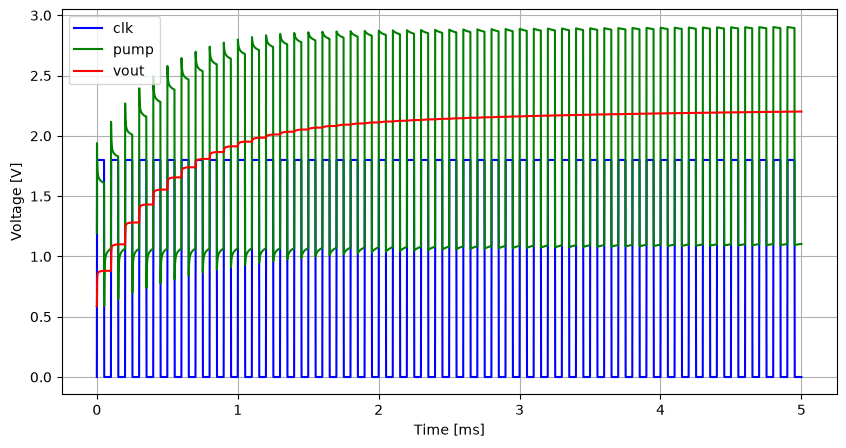

Final Vout = 2.201 V


In [24]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
import matplotlib.pyplot as plt

# 電源・クロック条件
VIN = 1.8 @ u_V
FCLK = 10 @ u_kHz
PERIOD = 1 / FCLK

circuit = Circuit("Voltage Doubler Charge Pump")

# 入力電源
circuit.V("in", "vin", circuit.gnd, VIN)

# 0 V <-> 1.8 V のクロック
circuit.PulseVoltageSource(
    "clk", "clk", circuit.gnd,
    initial_value=0 @ u_V,
    pulsed_value=VIN,
    delay_time=0 @ u_s,
    rise_time=1 @ u_us,
    fall_time=1 @ u_us,
    pulse_width=PERIOD / 2,
    period=PERIOD,
)

# ダイオードモデル
# 実回路ではショットキーダイオードやMOSFET同期整流へ置き換える
circuit.model("DCP", "D", IS=1e-15, N=1.05, RS=0.5)

# Charge pump 本体:
# clk --- Cfly --- pump
# vin --- D1 ----> pump --- D2 ----> vout
circuit.D("1", "vin", "pump", model="DCP")

# 抵抗を入れることで電圧のスパイクを安定させる
circuit.R("fly", "clk", "fly", 1 @ u_Ohm)
circuit.C("fly", "fly", "pump", 1 @ u_uF)
# circuit.C("fly", "clk", "pump", 1 @ u_uF)
circuit.D("2", "pump", "vout", model="DCP")

# 出力平滑コンデンサと負荷
circuit.C("out", "vout", circuit.gnd, 4.7 @ u_uF)
circuit.R("load", "vout", circuit.gnd, 100 @ u_kOhm)

# 過渡解析
simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.transient(step_time=PERIOD / 200, end_time=5 @ u_ms)

# 波形表示用
# ｘ軸：時間(time)、ｙ軸：電圧(vin, vout)
time = analysis.time.as_ndarray()*1e3  # ms
clk = analysis["clk"].as_ndarray()
pump = analysis["pump"].as_ndarray()
vout = analysis['vout'].as_ndarray()

plt.figure(figsize=(10, 5))
plt.plot(time, clk, label='clk', color='blue')
plt.plot(time, pump, label='pump', color='green')
plt.plot(time, vout, label='vout', color='red')
plt.xlabel('Time [ms]')
plt.ylabel('Voltage [V]')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Vout = {float(analysis['vout'][-1]):.3f} V")

In [26]:
vf_d1 = (analysis["vin"] - analysis["pump"]).as_ndarray()
vf_d2 = (analysis["pump"] - analysis["vout"]).as_ndarray()

In [18]:
print(f"D1 max forward voltage: {vf_d1[vf_d1 > 0].max():.3f} V")
print(f"D2 max forward voltage: {vf_d2[vf_d2 > 0].max():.3f} V")

D1 max forward voltage: 1.944 V
D2 max forward voltage: 2.392 V


In [27]:
import numpy as np

# 立上り・立下りの過渡を除くため、解析の後半2周期を対象にする
steady_state = time > (time[-1] - 2 * float(PERIOD * 1e3))

vf_d1_forward = vf_d1[steady_state & (vf_d1 > 0)]
vf_d2_forward = vf_d2[steady_state & (vf_d2 > 0)]

print(f"D1 VF (99 percentile): {np.percentile(vf_d1_forward, 99):.3f} V")
print(f"D2 VF (99 percentile): {np.percentile(vf_d2_forward, 99):.3f} V")

D1 VF (99 percentile): 0.706 V
D2 VF (99 percentile): 0.704 V
